<a href="https://colab.research.google.com/github/yonaanda/Analisis-Visualisasi-Data/blob/main/Tugas%204/Customer_Personality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# EDA

In [5]:
df.shape

(2240, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Dari output di atas, diketahui bahwa


1.   Terdapat missing value di kolom income
2.   Kolom Dt_Customer yang berisi tanggal customer bergabung tidak bertipe data DateTime
3. Terdapat beberapa data kategori (dtype: object) segingga perlu dilakkan encode menjadi numeric

In [7]:
df.nunique()

,0
ID,2240
Year_Birth,59
Education,5
Marital_Status,8
Income,1974
Kidhome,3
Teenhome,3
Dt_Customer,663
Recency,100
MntWines,776


Semua value pada cell Z_CostContact dan Z_Revenue berisi sama, sehingga dapat dihapus

In [8]:
data = df.copy()
data = data.drop(columns=["Z_CostContact", "Z_Revenue"],axis=1)
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,3,6,5,0,0,0,0,0,0,0


**Handling Missing Value**
Dengan memasukkan nilai rata rata dari kolom Income untuk data yang null

In [9]:
data['Income'] = data['Income'].fillna(data['Income'].mean())
data.isna().any()

,0
ID,False
Year_Birth,False
Education,False
Marital_Status,False
Income,False
Kidhome,False
Teenhome,False
Dt_Customer,False
Recency,False
MntWines,False


**Mengubah Kelompok pada Kolom Marital_Status**


In [10]:
data['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [11]:
data['Marital_Status'] = data['Marital_Status'].replace(['Married', 'Together'],'Relationship')
data['Marital_Status'] = data['Marital_Status'].replace(['Divorced', 'Widow', 'Alone', 'YOLO', 'Absurd'],'Single')
data['Marital_Status'].value_counts()

,count
Marital_Status,
Relationship,1444
Single,796


**Mengkombinasikan beberapa dataframe menjadi 1 kolom untuk mengurangi dimensi**

In [12]:
data['Kids'] = data['Kidhome'] + data['Teenhome']
data['Expenses'] = data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] + data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds']
data['TotalAcceptedCmp'] = data['AcceptedCmp1'] + data['AcceptedCmp2'] + data['AcceptedCmp3'] + data['AcceptedCmp4'] + data['AcceptedCmp5'] + data['Response']
data['NumTotalPurchases'] = data['NumWebPurchases'] + data['NumCatalogPurchases'] + data['NumStorePurchases'] + data['NumDealsPurchases']

In [13]:
col_del = ["AcceptedCmp1" , "AcceptedCmp2", "AcceptedCmp3" , "AcceptedCmp4","AcceptedCmp5", "Response","NumWebVisitsMonth", "NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumDealsPurchases" , "Kidhome", "Teenhome","MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
data=data.drop(columns=col_del,axis=1)
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,Complain,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases
0,5524,1957,Graduation,Single,58138.0,04-09-2012,58,0,0,1617,1,25
1,2174,1954,Graduation,Single,46344.0,08-03-2014,38,0,2,27,0,6
2,4141,1965,Graduation,Relationship,71613.0,21-08-2013,26,0,0,776,0,21
3,6182,1984,Graduation,Relationship,26646.0,10-02-2014,26,0,1,53,0,8
4,5324,1981,PhD,Relationship,58293.0,19-01-2014,94,0,1,422,0,19


**Menambah kolom "Age"**

In [14]:
data['Age'] = 2026 - data["Year_Birth"]

**Mengubah kategori kolom "Education" menjadi UG (Undergraduate) dan PG (Postgraduate)**

In [15]:
data['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [16]:
data['Education'] = data['Education'].replace(['PhD','2n Cycle','Graduation', 'Master'],'PG')
data['Education'] = data['Education'].replace(['Basic'], 'UG')

**Mengubah tipe data Dt_Customer menjadi dateTime**

In [17]:
data["Dt_Customer"] = pd.to_datetime(
    data["Dt_Customer"],
    format="%d-%m-%Y")
data['day_engaged'] = (data['Dt_Customer'].max() - data['Dt_Customer']).dt.days

**Menghapus data yang redudant**

In [18]:
data=data.drop(columns=["ID", "Dt_Customer", "Year_Birth", "Dt_Customer", "Recency", "Complain"],axis=1)
data.shape

(2240, 9)

In [19]:
data.describe()

,Income,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,Age,day_engaged
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52247.251354,0.950446,605.798214,0.446875,14.862054,57.194196,353.582143
std,25037.797168,0.751803,602.249288,0.890543,7.677173,11.984069,202.122512
min,1730.000000,0.000000,5.000000,0.000000,0.000000,30.000000,0.000000
25%,35538.750000,0.000000,68.750000,0.000000,8.000000,49.000000,180.750000
50%,51741.500000,1.000000,396.000000,0.000000,15.000000,56.000000,355.500000
75%,68289.750000,1.000000,1045.500000,1.000000,21.000000,67.000000,529.000000
max,666666.000000,3.000000,2525.000000,5.000000,44.000000,133.000000,699.000000


<Axes: >

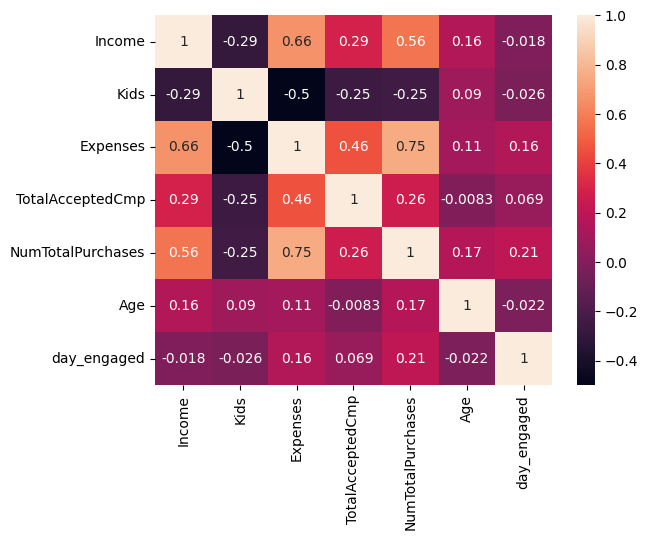

In [20]:
sns.heatmap(data.corr(numeric_only=True), annot=True)

**Label Encoding untuk Data Kategorikal**

In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

lbl_encode = LabelEncoder()
data['Education'] = lbl_encode.fit_transform(data['Education'])
data['Marital_Status'] = lbl_encode.fit_transform(data['Marital_Status'])


**Standardization**

In [22]:
data1=data.copy()
scaled_features = StandardScaler().fit_transform(data1.values)
scaled_features_df = pd.DataFrame(scaled_features, index=data1.index, columns=data1.columns)
scaled_features_df.head()

,Education,Marital_Status,Income,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,Age,day_engaged
0,-0.157171,1.346874,0.235327,-1.264505,1.679417,0.621248,1.320826,0.985345,1.531185
1,-0.157171,1.346874,-0.235826,1.396361,-0.961275,-0.501912,-1.154596,1.235733,-1.190545
2,-0.157171,-0.742460,0.773633,-1.264505,0.282673,-0.501912,0.799685,0.317643,-0.205773
3,-0.157171,-0.742460,-1.022732,0.065928,-0.918094,-0.501912,-0.894025,-1.268149,-1.061881
4,-0.157171,-0.742460,0.241519,0.065928,-0.305254,-0.501912,0.539114,-1.017761,-0.953012


# Membuat Model Clustering

**Elbow Method**

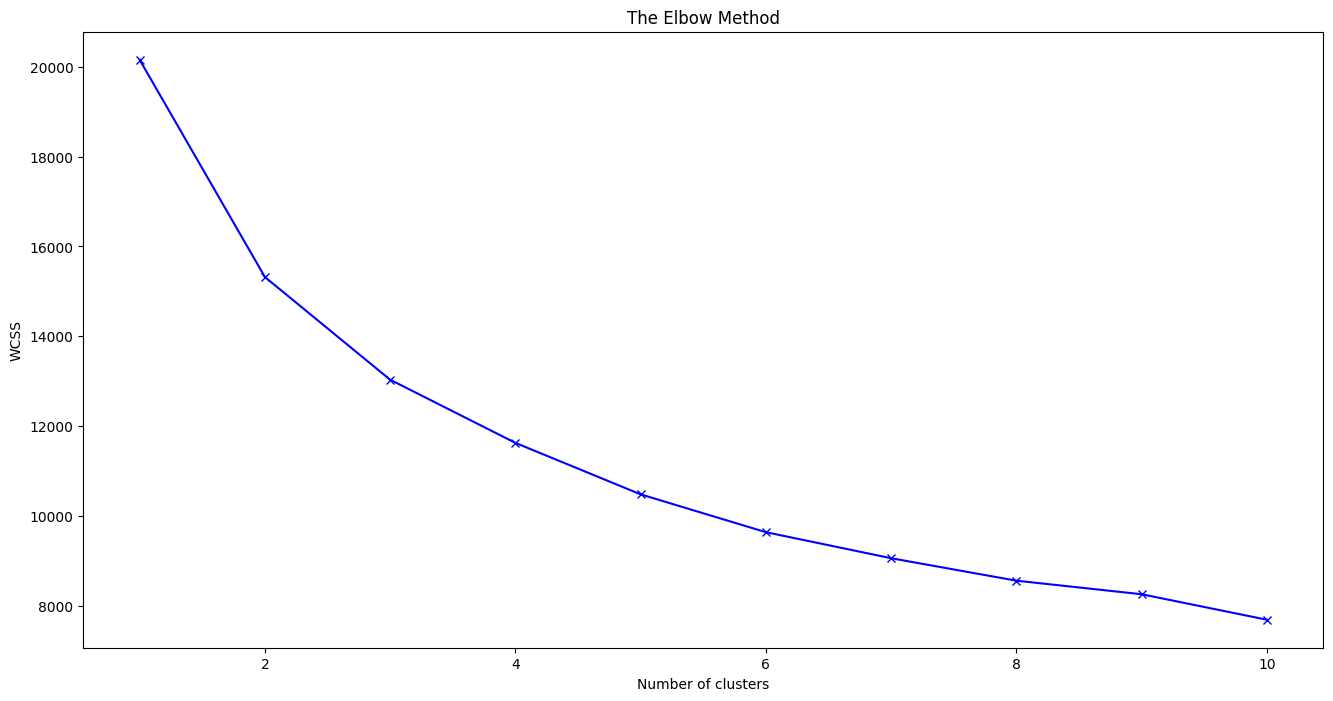

In [23]:
from sklearn.cluster import KMeans

wcss=[]
for i in range (1,11):
 kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
 kmeans.fit(scaled_features_df)
 wcss.append(kmeans.inertia_)
plt.figure(figsize=(16,8))
plt.plot(range(1,11),wcss, 'bx-')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

**Silhouette Score**

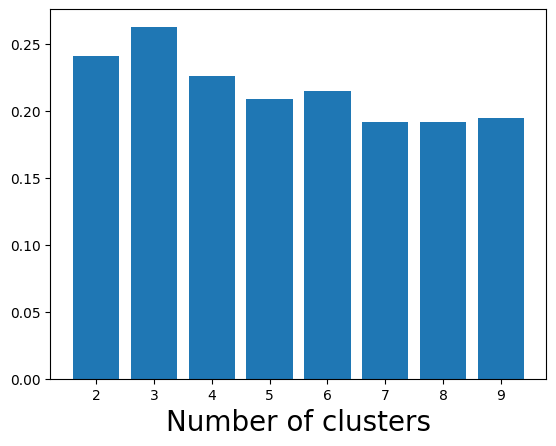

In [24]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2,10):
    m1 = KMeans(n_clusters=i, random_state=42)
    c = m1.fit_predict(scaled_features_df)
    silhouette_scores.append(silhouette_score(scaled_features_df, c))
plt.bar(range(2,10), silhouette_scores)
plt.xlabel('Number of clusters', fontsize = 20)
plt.show()

**Model Building**

In [25]:
# Training a predicting using K-Means Algorithm.

kmeans = KMeans(n_clusters=3, random_state=42).fit(scaled_features_df)
pred =kmeans.predict(scaled_features_df)

# Appending those cluster value into main dataframe (without standard-scalar)
data['cluster'] = pred + 1

In [26]:
data.head()

,Education,Marital_Status,Income,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,Age,day_engaged,cluster
0,0,1,58138.0,0,1617,1,25,69,663,2
1,0,1,46344.0,2,27,0,6,72,113,1
2,0,0,71613.0,0,776,0,21,61,312,2
3,0,0,26646.0,1,53,0,8,42,139,1
4,0,0,58293.0,1,422,0,19,45,161,1


In [27]:
scaled_features_df.head()

,Education,Marital_Status,Income,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,Age,day_engaged
0,-0.157171,1.346874,0.235327,-1.264505,1.679417,0.621248,1.320826,0.985345,1.531185
1,-0.157171,1.346874,-0.235826,1.396361,-0.961275,-0.501912,-1.154596,1.235733,-1.190545
2,-0.157171,-0.742460,0.773633,-1.264505,0.282673,-0.501912,0.799685,0.317643,-0.205773
3,-0.157171,-0.742460,-1.022732,0.065928,-0.918094,-0.501912,-0.894025,-1.268149,-1.061881
4,-0.157171,-0.742460,0.241519,0.065928,-0.305254,-0.501912,0.539114,-1.017761,-0.953012


**Clustering**

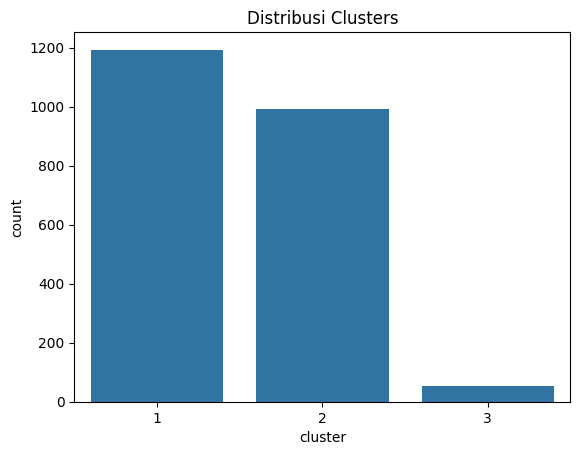

In [28]:
pl = sns.countplot(x=data["cluster"])
pl.set_title("Distribusi Clusters")
plt.show()

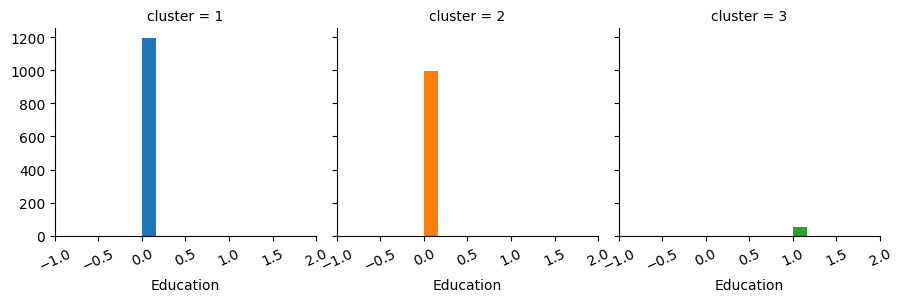

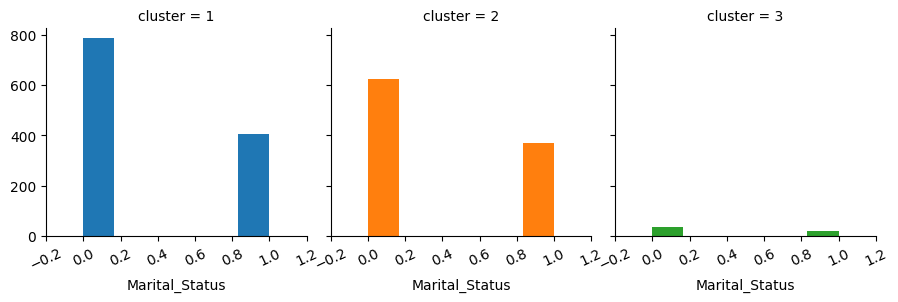

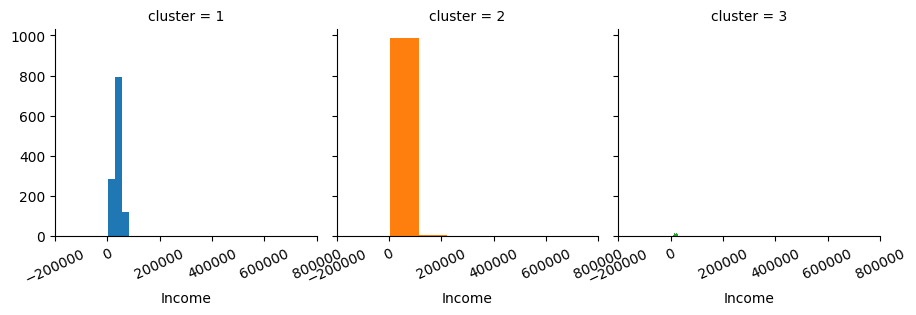

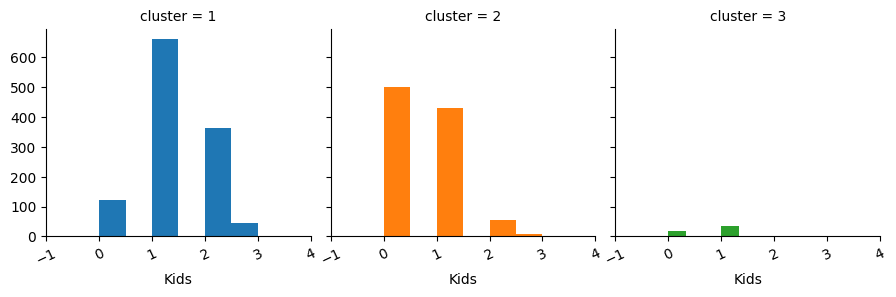

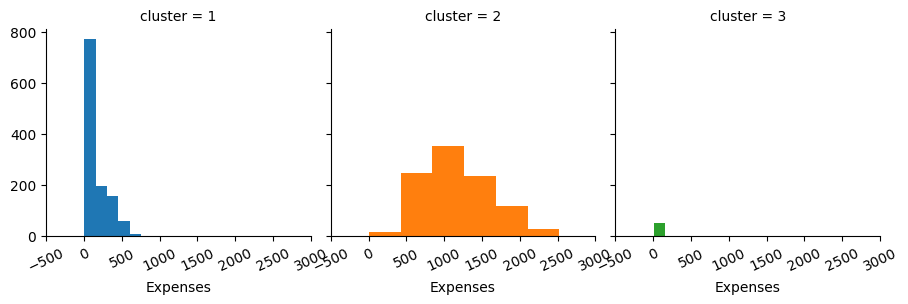

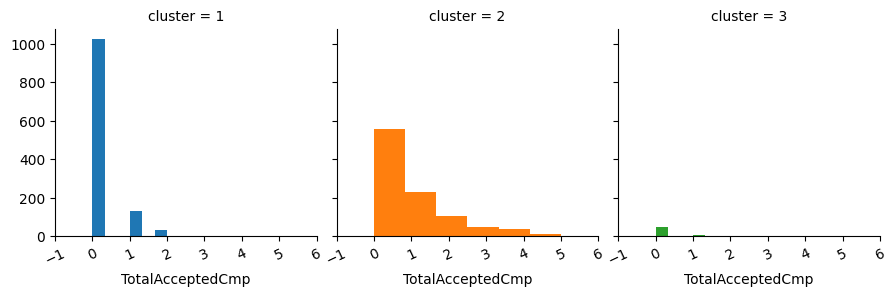

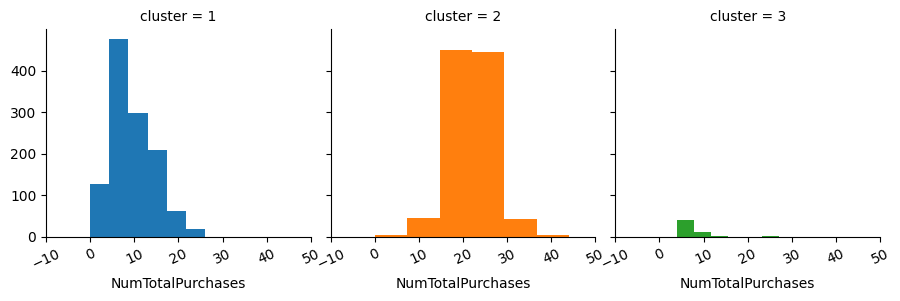

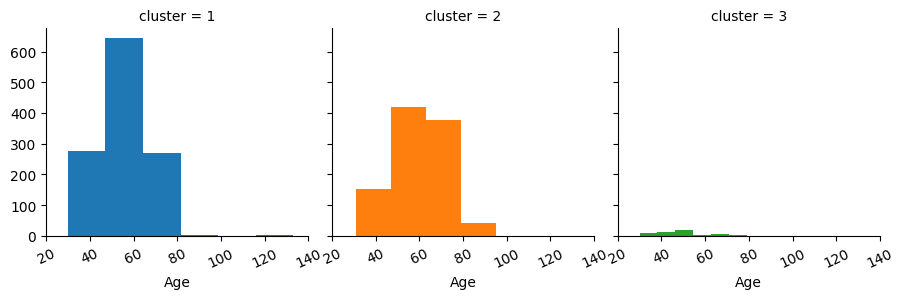

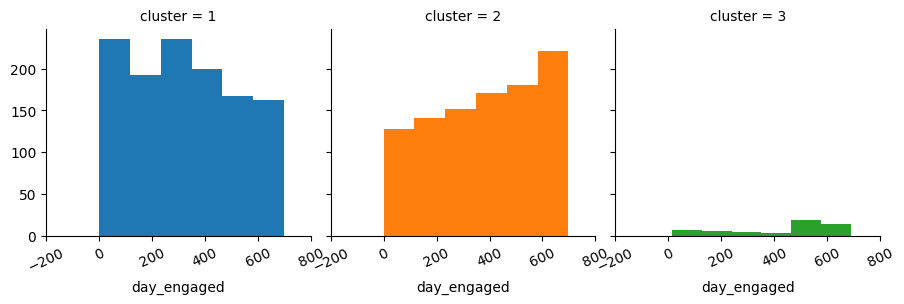

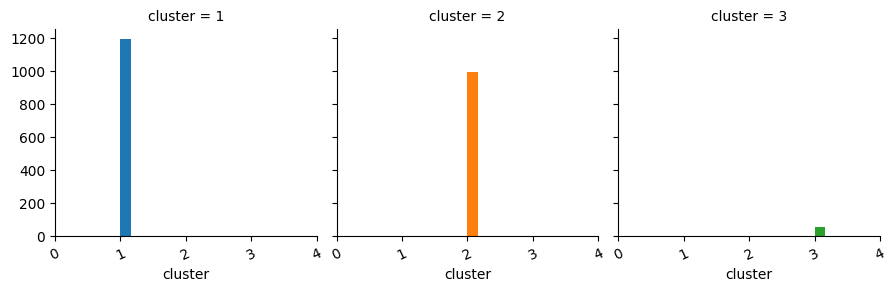

In [29]:
plt.rcParams.update(plt.rcParamsDefault)
for i in data:
    diag = sns.FacetGrid(data, col = "cluster", hue = "cluster")
    diag.map(plt.hist, i, bins=6, ec="k")
    diag.set_xticklabels(rotation=25)
plt.show()

**Kesimpulan**

Berdasarkan informasi di atas, pelanggan dapat dibagi menjadi tiga kelompok:
1.   Pelanggan Sangat Aktif → termasuk dalam kluster pertama
2.   Pelanggan Cukup Aktif → termasuk dalam kluster kedua
3. Pelanggan Kurang Aktif → termasuk dalam kluster ketiga



**Karakteristik Pelanggan Sangat Aktif**

* Education  
Mayoritas berasal dari latar belakang pascasarjana (PG).
* Marital_Status  
Jumlah pelanggan yang sedang menjalin hubungan sekitar dua kali lebih banyak dibandingkan yang masih lajang.
* Income  
Pendapatan sedikit lebih rendah dibandingkan pelanggan yang cukup aktif.
* Kids  
Memiliki lebih banyak anak dibandingkan kelompok lain (rata-rata 1 anak).
* Expenses  
Pengeluaran lebih rendah dibandingkan pelanggan cukup aktif, dengan rata-rata sekitar 100–200 unit uang.
* Age  
Berada di rentang 25–75 tahun, dengan mayoritas berusia 40–50 tahun.
* day_engaged
Lebih loyal karena terhubung dengan perusahaan dalam jangka waktu lebih lama.

**Karakteristik Pelanggan Cukup Aktif**
* Education  
Sebagian besar juga berasal dari latar belakang pascasarjana (PG).
* Marital_Status
Jumlah pelanggan yang menjalin hubungan sedikit lebih banyak dibandingkan yang lajang.
* Income
Pendapatan lebih tinggi dibandingkan kelompok lain.
* Kids
Memiliki lebih sedikit anak dibandingkan pelanggan sangat aktif (sebagian besar tidak memiliki anak).
* Expenses  
Pengeluaran lebih tinggi, rata-rata sekitar 500–2000 unit uang.
* Age
Berada di rentang 25–75 tahun, dengan mayoritas berusia 35–60 tahun.
* day_engaged
Sedikit kurang terlibat dibandingkan pelanggan sangat aktif.

**Karakteristik Pelanggan Kurang Aktif**
* Education  
Mayoritas berasal dari latar belakang sarjana (UG).
* Marital_Status
Jumlah pelanggan yang menjalin hubungan hampir sama dengan yang lajang.
* Income
Pendapatan sangat rendah, bahkan bisa dikatakan hampir tidak ada.
* Kids
Hanya sebagian kecil yang memiliki anak.
* Expenses
Pengeluaran sangat rendah atau hampir tidak ada.
* Age
Berada di rentang 15–30 tahun.
* day_engage
Tidak terlalu lama terhubung dengan perusahaan.